In [2]:
import pandas as pd

df = pd.read_pickle(r"C:\Users\shash\Downloads\preprocessed_data.pkl")

In [3]:
df

,price,year,manufacturer,model,condition,number_of_cylinders,fuel_type,distance_driven_km,vehicle_title_status,transmission_type,drive_type,vehicle_size,vehicle_type,paint_color
0,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,fwd,NaN,sedan,NaN
426876,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,fwd,NaN,sedan,red
426877,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,NaN,NaN,hatchback,white
426878,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,fwd,NaN,sedan,silver


In [11]:
import pandas as pd

pd.options.display.float_format = "{:,.2f}".format

# 🚗 Exploratory Data Analysis (EDA) - Used Car Price Prediction

## 📌 Objective
The objective of Exploratory Data Analysis (EDA) is to understand the dataset, identify patterns, detect missing values and outliers, analyze relationships between variables, and prepare the data for building an accurate used car price prediction model.

---

# 📊 Exploratory Data Analysis (EDA) for Numerical Columns
### Numerical Columns

- **Price:** Selling price of the used car (Target Variable).
- **Distance_Driven_km:** Total distance the vehicle has traveled, measured in kilometers.

# 📈 EDA for Price

In [6]:

price_overview = pd.DataFrame({
    "Property": [
        "Shape",
        "First 5 Values",
        "Last 5 Values",
        "Random 5 Values",
        "Data Type",
        "Non-Missing Values",
        "Missing Values",
        "Unique Values"
    ],
    
    "Value": [
        df["price"].shape,
        df["price"].head().tolist(),
        df["price"].tail().tolist(),
        df["price"].sample(5, random_state=42).tolist(),
        df["price"].dtype,
        df["price"].count(),
        df["price"].isnull().sum(),
        df["price"].nunique()
    ]
})

price_overview

,Property,Value
0,Shape,"(426880,)"
1,First 5 Values,"[6000, 11900, 21000, 1500, 4900]"
2,Last 5 Values,"[23590, 30590, 34990, 28990, 30590]"
3,Random 5 Values,"[36990, 27995, 78423, 14000, 676]"
4,Data Type,int64
5,Non-Missing Values,426880
6,Missing Values,0
7,Unique Values,15655


In [12]:
statistics_summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Minimum",
        "Maximum",
        "Range",
        "Variance",
        "Standard Deviation",
        "Interquartile Range (IQR)",
        "Skewness",
        "Kurtosis"
    ],

    "Value": [
        round(df["price"].mean(), 2),
        round(df["price"].median(), 2),
        round(df["price"].mode().iloc[0], 2),
        round(df["price"].min(), 2),
        round(df["price"].max(), 2),
        round(df["price"].max() - df["price"].min(), 2),
        round(df["price"].var(), 2),
        round(df["price"].std(), 2),
        round(df["price"].quantile(0.75) - df["price"].quantile(0.25), 2),
        round(df["price"].skew(), 2),
        round(df["price"].kurt(), 2)
    ]
})

statistics_summary

,Statistic,Value
0,Mean,"75,199.03"
1,Median,"13,950.00"
2,Mode,0.00
3,Minimum,0.00
4,Maximum,"3,736,928,711.00"
5,Range,"3,736,928,711.00"
6,Variance,"148,407,998,957,162.50"
7,Standard Deviation,"12,182,282.17"
8,Interquartile Range (IQR),"20,585.75"
9,Skewness,254.41


## 📌 Key Observations

- The **mean price is significantly higher than the median**, indicating that the price distribution is **highly right-skewed**.

- The **mode of the price column is 0**, suggesting the presence of invalid, missing, or incorrectly recorded price values that require further investigation.

- The **minimum price is also 0**, which is unrealistic for a used car and may indicate data quality issues.

- The **maximum price is extremely high (3,736,928,711)**, indicating the presence of one or more extreme outliers or possible data entry errors.

- The **large range between the minimum and maximum prices** shows that the dataset contains a wide variation in car prices.

- The **high standard deviation** indicates that the price values are widely dispersed around the mean.

- The **Interquartile Range (IQR) is relatively small compared to the overall range**, suggesting that most cars fall within a relatively narrow price range while a few extreme values stretch the distribution.

- The **very high skewness value (254.41)** confirms that the distribution is **extremely positively skewed**, with a small number of high-priced vehicles heavily influencing the average price.

- The **very high kurtosis value (69,205.09)** indicates the presence of **extreme outliers and heavy tails** in the price distribution.

- Overall, the **price column contains potential outliers and possible data quality issues** that should be investigated and treated before feature engineering and model training.

In [13]:
five_number_summary = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "First Quartile (Q1)",
        "Median (Q2)",
        "Third Quartile (Q3)",
        "Maximum"
    ],
    "Value": [
        df["price"].min(),
        df["price"].quantile(0.25),
        df["price"].median(),
        df["price"].quantile(0.75),
        df["price"].max()
    ]
})

five_number_summary

,Statistic,Value
0,Minimum,0.00
1,First Quartile (Q1),"5,900.00"
2,Median (Q2),"13,950.00"
3,Third Quartile (Q3),"26,485.75"
4,Maximum,"3,736,928,711.00"


### Observation: Price Distribution

- The **`price`** feature is **highly right-skewed**, indicating that most cars are priced within a relatively small range, while a few cars have extremely high prices.
- The histogram and box plot reveal the presence of **several extreme outliers** on the higher end of the price distribution.
- Approximately **32,985 records have a price of 0**.
- Since a selling price of **0 is unrealistic for a car**, these values may represent **missing prices, unavailable prices, or data entry issues**.
- Further investigation is required before deciding whether to remove, impute, or retain these records for model building.

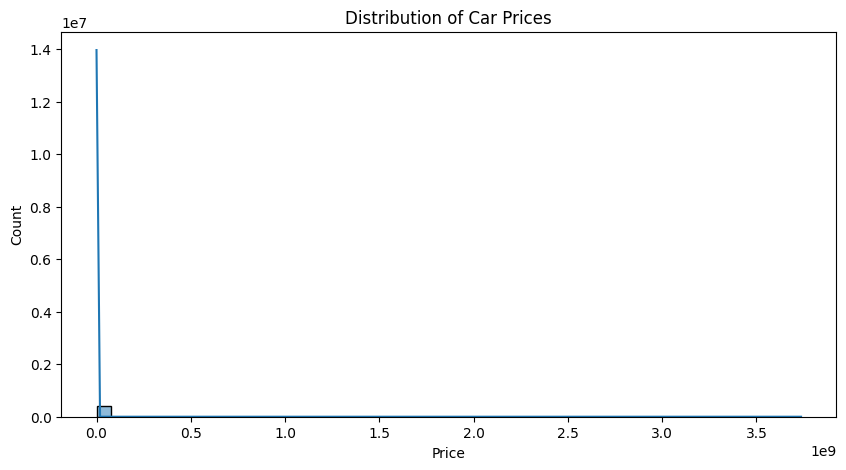

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

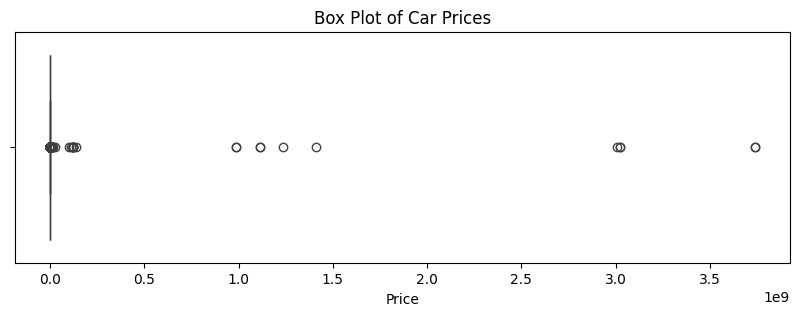

In [35]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df["price"])
plt.title("Box Plot of Car Prices")
plt.xlabel("Price")
plt.show()

In [32]:
df.loc[df["price"] == 0, ["vehicle_title_status", "condition"]]["vehicle_title_status"].value_counts()

vehicle_title_status
clean         32250
rebuilt          79
salvage          31
missing          17
parts only        9
lien              1
Name: count, dtype: int64

In [33]:
df.loc[df["price"] == 0, ["vehicle_title_status", "condition"]]["condition"].value_counts()

condition
excellent    6542
good         2301
like new     1118
new           173
fair           40
salvage         6
Name: count, dtype: int64

### Observation: Relationship between Price = 0 and Vehicle Condition

- The majority of vehicles with a price of **0** have a **Clean** title status.
- Most of these vehicles are also listed in **Excellent**, **Good**, or **Like New** condition.
- Therefore, there is **no strong evidence** to suggest that vehicles have a price of **0** because they are damaged or in poor condition.
- This indicates that a price of **0** is more likely to represent **missing, unavailable, or incorrectly recorded price information** rather than the actual selling price of the vehicle.

In [39]:
import numpy as np

df["price"] = df["price"].replace(0, np.nan)

np.int64(32895)

In [38]:
from pyampute.exploration.mcar_statistical_tests import MCARTest

mcar = MCARTest(method="little")

mcar.little_mcar_test(df["price"])

AttributeError: 'numpy.dtypes.Int64DType' object has no attribute 'index'